# Strategy Exploration

Interactive walkthrough of the `backtester` framework: load data, run the momentum and mean-reversion strategies, inspect metrics, and visualize results.

Run this from the project root with the project's virtual environment as the kernel (`pip install -e ".[dev]"` first).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import matplotlib.pyplot as plt
%matplotlib inline

from backtester.data import load_csv
from backtester.engine import BacktestEngine
from backtester.strategies import MomentumStrategy, MeanReversionStrategy
from backtester.validation import walk_forward_validation
from backtester.visualization import plot_equity_curve, plot_signals, plot_trade_pnl

data = load_csv(os.path.join('..', 'data', 'sample_ohlcv.csv'))
data.head()

,open,high,low,close,volume
date,,,,,
2018-01-01,100.0000,100.6915,99.6253,100.5552,2362006.0
2018-01-02,100.3612,100.5617,98.5397,98.7435,2973445.0
2018-01-03,98.6352,100.2057,98.0534,100.0754,2802765.0
2018-01-04,100.2432,101.8428,99.7777,101.7660,3908865.0
2018-01-05,101.7668,102.1956,98.2611,98.3394,2929045.0


## Momentum strategy

In [2]:
momentum = MomentumStrategy(lookback=20)
momentum_result = BacktestEngine(data, momentum, commission_bps=5, slippage_bps=5).run()
momentum_result.summary()

{'cumulative_return': np.float64(-0.41117520698833576),
 'annualized_return': np.float64(-0.12505959533891353),
 'annualized_volatility': np.float64(0.1694423943328396),
 'sharpe_ratio': np.float64(-0.7033142082409958),
 'sortino_ratio': np.float64(-0.6574656803651375),
 'max_drawdown': np.float64(-0.49651074854364763),
 'max_drawdown_peak_date': Timestamp('2018-03-13 00:00:00'),
 'max_drawdown_trough_date': Timestamp('2020-11-24 00:00:00'),
 'max_drawdown_recovery_date': None,
 'max_drawdown_duration_bars': 948,
 'n_trades': 17,
 'win_rate': np.float64(0.29411764705882354),
 'profit_factor': np.float64(0.26476446296311734),
 'avg_trade_return': np.float64(-0.028868898997644176),
 'trade_return_std': np.float64(0.06202832489136629),
 'trade_return_skew': np.float64(0.5608442064131541),
 'trade_return_kurtosis': np.float64(-0.2763803426416458),
 'best_trade_return': np.float64(0.10982591970428615),
 'worst_trade_return': np.float64(-0.10963440331298384)}

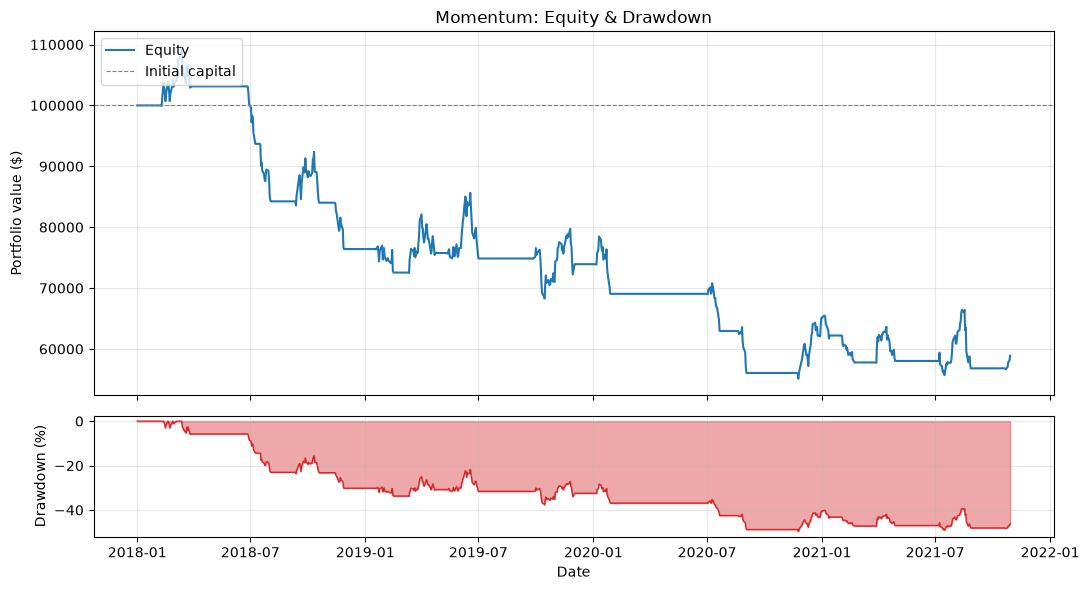

In [3]:
plot_equity_curve(momentum_result, title='Momentum: Equity & Drawdown')
plt.show()

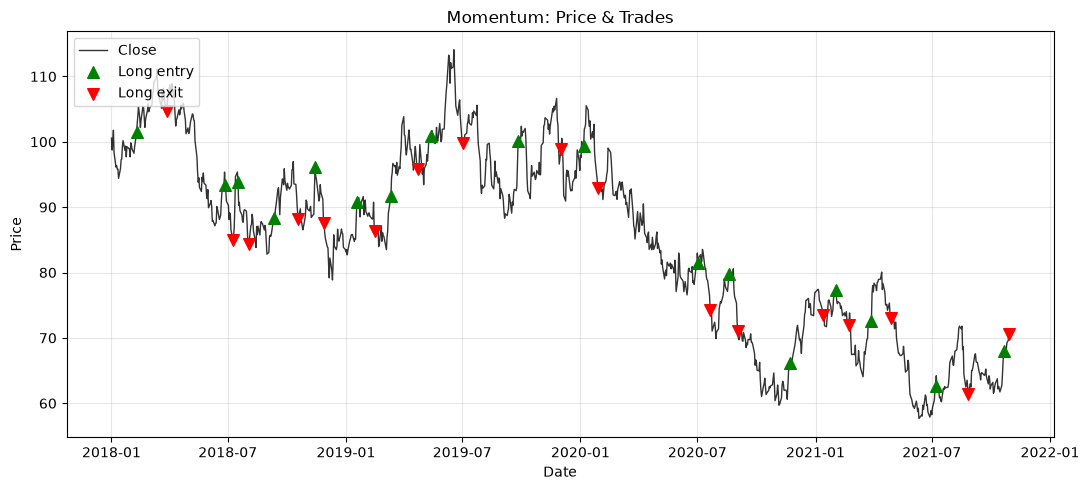

In [4]:
plot_signals(momentum_result, title='Momentum: Price & Trades')
plt.show()

## Mean-reversion strategy

In [5]:
mean_rev = MeanReversionStrategy(window=20, entry_z=2.0, exit_z=0.5)
mean_rev_result = BacktestEngine(data, mean_rev, commission_bps=5, slippage_bps=5).run()
mean_rev_result.summary()

{'cumulative_return': np.float64(0.09928726204421157),
 'annualized_return': np.float64(0.0241660885475532),
 'annualized_volatility': np.float64(0.14569469187867498),
 'sharpe_ratio': np.float64(0.236564784026272),
 'sortino_ratio': np.float64(0.2017708564417293),
 'max_drawdown': np.float64(-0.23003455687447327),
 'max_drawdown_peak_date': Timestamp('2021-01-21 00:00:00'),
 'max_drawdown_trough_date': Timestamp('2021-06-11 00:00:00'),
 'max_drawdown_recovery_date': None,
 'max_drawdown_duration_bars': 179,
 'n_trades': 29,
 'win_rate': np.float64(0.6206896551724138),
 'profit_factor': np.float64(1.1660880325434824),
 'avg_trade_return': np.float64(0.004749398586878626),
 'trade_return_std': np.float64(0.05364254048993698),
 'trade_return_skew': np.float64(-1.7710646974083024),
 'trade_return_kurtosis': np.float64(6.016422830126798),
 'best_trade_return': np.float64(0.10509502921768815),
 'worst_trade_return': np.float64(-0.19336158429330214)}

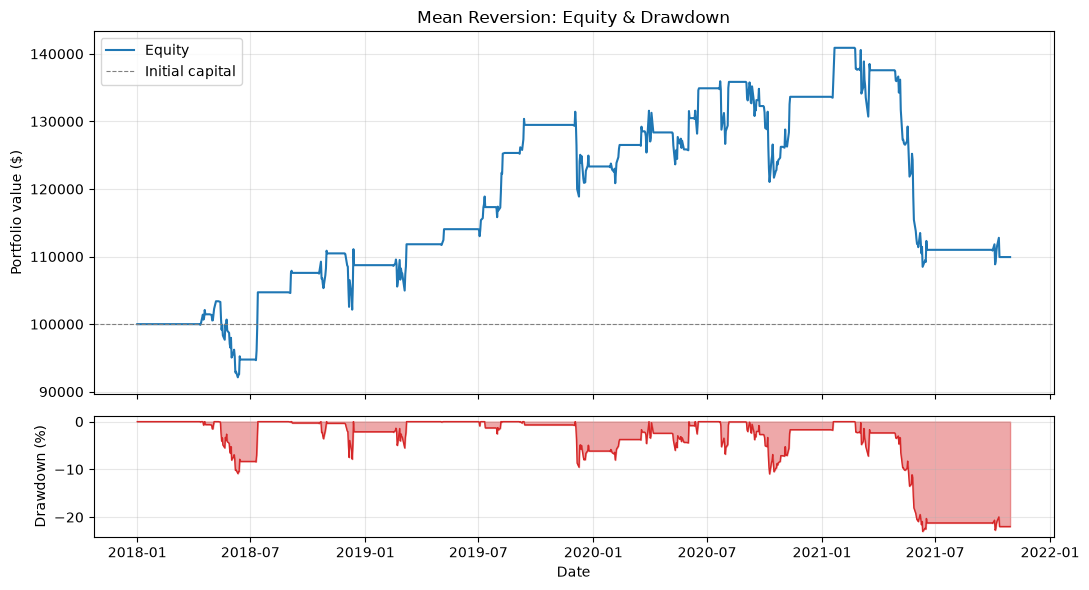

In [6]:
plot_equity_curve(mean_rev_result, title='Mean Reversion: Equity & Drawdown')
plt.show()

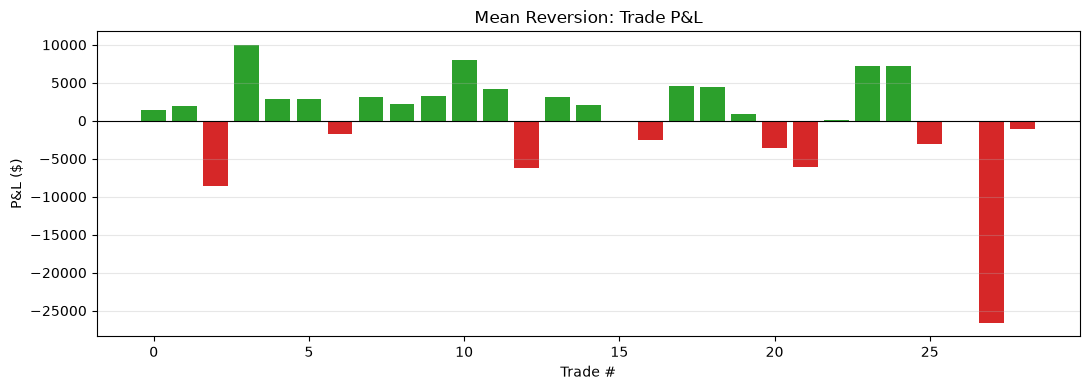

In [7]:
plot_trade_pnl(mean_rev_result, title='Mean Reversion: Trade P&L')
plt.show()

## Walk-forward validation

Grid-search the momentum lookback in-sample on each rolling train window, then evaluate the winning parameters out-of-sample on the following test window.

In [8]:
wf_result = walk_forward_validation(
    data, MomentumStrategy,
    param_grid={'lookback': [10, 20, 30, 50]},
    train_size=180, test_size=60,
    optimize_metric='sharpe_ratio',
)
wf_result.summary_table()

,window,train_start,train_end,test_start,test_end,best_params,train_sharpe,test_sharpe,train_return,test_return,test_max_drawdown,test_n_trades
0,0,2018-01-01,2018-09-07,2018-09-10,2018-11-30,{'lookback': 50},-1.251800,0.000000,-0.082498,0.000000,0.000000,0
1,1,2018-03-26,2018-11-30,2018-12-03,2019-02-22,{'lookback': 50},-0.992199,0.000000,-0.095729,0.000000,0.000000,0
2,2,2018-06-18,2019-02-22,2019-02-25,2019-05-17,{'lookback': 10},-0.852962,0.762879,-0.119042,0.029536,-0.090545,3
3,3,2018-09-10,2019-05-17,2019-05-20,2019-08-09,{'lookback': 50},0.616120,0.000000,0.055431,0.000000,0.000000,0
4,4,2018-12-03,2019-08-09,2019-08-12,2019-11-01,{'lookback': 10},0.470356,0.994174,0.052380,0.040416,-0.098450,2
5,5,2019-02-25,2019-11-01,2019-11-04,2020-01-24,{'lookback': 10},0.248255,-2.031649,0.021512,-0.099874,-0.124889,2
6,6,2019-05-20,2020-01-24,2020-01-27,2020-04-17,{'lookback': 10},-0.684467,-2.684635,-0.110020,-0.071172,-0.103147,2
7,7,2019-08-12,2020-04-17,2020-04-20,2020-07-10,{'lookback': 10},-0.544536,-0.819161,-0.079027,-0.040254,-0.095726,3
8,8,2019-11-04,2020-07-10,2020-07-13,2020-10-02,{'lookback': 50},0.000000,0.000000,0.000000,0.000000,0.000000,0
9,9,2020-01-27,2020-10-02,2020-10-05,2020-12-25,{'lookback': 50},0.000000,-0.344661,0.000000,-0.007422,-0.033954,1


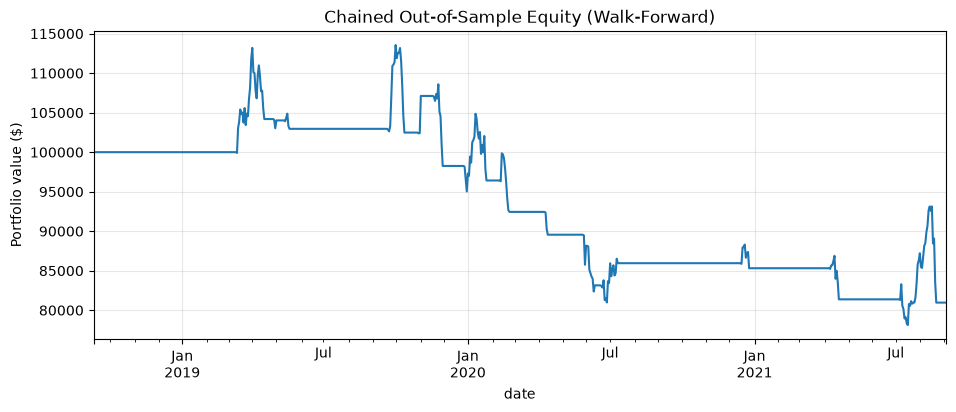

In [9]:
combined = wf_result.combined_out_of_sample_equity()
combined.plot(figsize=(11, 4), title='Chained Out-of-Sample Equity (Walk-Forward)')
plt.ylabel('Portfolio value ($)')
plt.grid(alpha=0.3)
plt.show()